In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('weatherAUS.csv')

print("=== ИССЛЕДОВАНИЕ ДАННЫХ ===")
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

=== ИССЛЕДОВАНИЕ ДАННЫХ ===
Размер датасета: (145460, 23)

Первые 5 строк:
         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressur

In [2]:
print("=== ИНФОРМАЦИЯ О ДАТАСЕТЕ ===")
print(df.info())
print("\n=== СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ ===")
print(df.describe())
print("\n=== КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ ===")
categorical_cols = df.select_dtypes(include=['object']).columns
print("Категориальные признаки:", list(categorical_cols))
for col in categorical_cols:
    if col != 'Date':
        print(f"\n{col}: {df[col].nunique()} уникальных значений")
        print(df[col].value_counts().head())

=== ИНФОРМАЦИЯ О ДАТАСЕТЕ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17 

=== ВИЗУАЛИЗАЦИЯ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ===


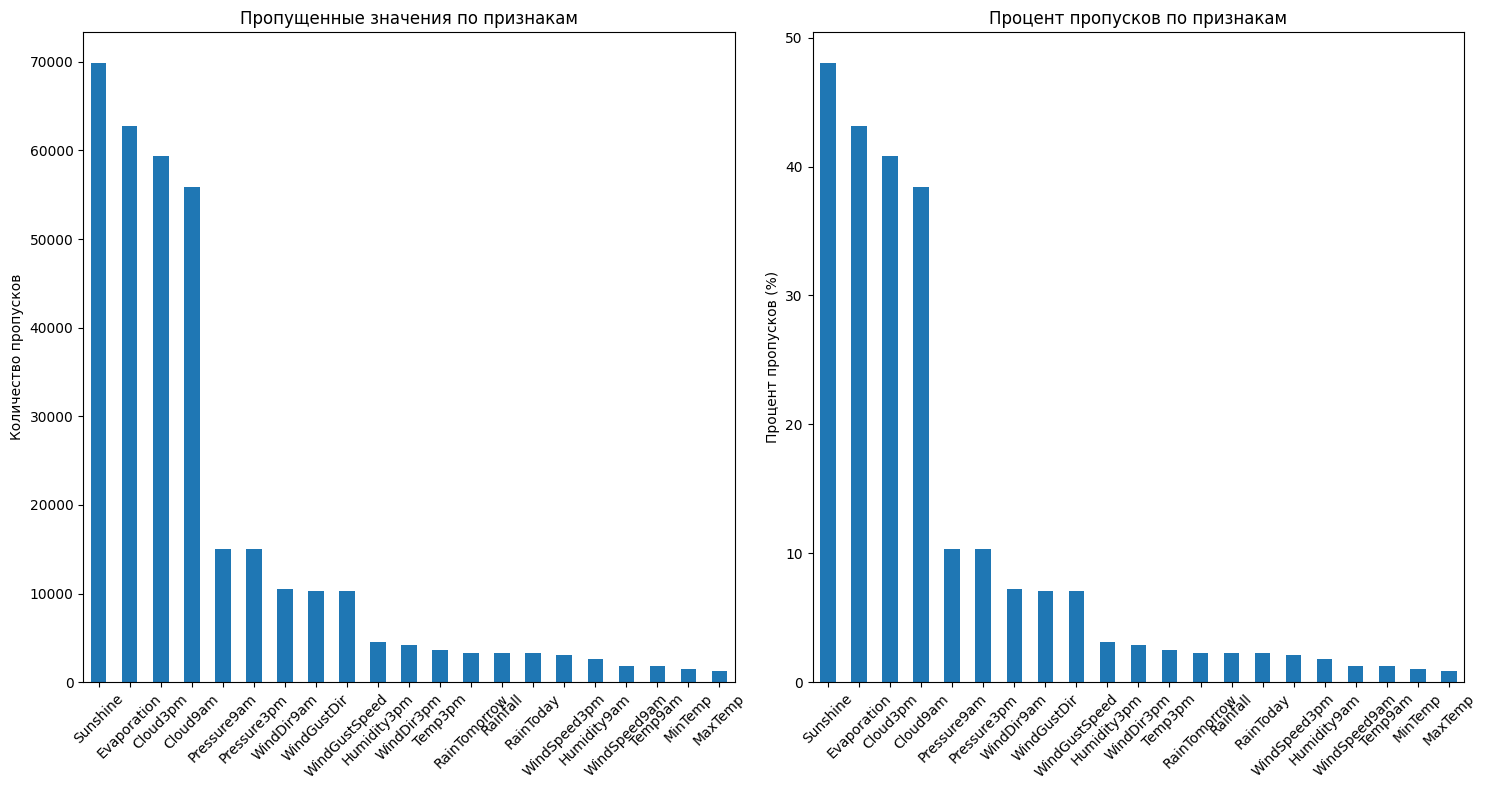


=== ПРОПУСКИ В ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===
Пропуски в RainTomorrow: 3267 (2.25%)


In [3]:
print("=== ВИЗУАЛИЗАЦИЯ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ===")

# Визуализация пропусков
plt.figure(figsize=(15, 8))
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_data / len(df)) * 100

plt.subplot(1, 2, 1)
missing_data[missing_data > 0].plot(kind='bar')
plt.title('Пропущенные значения по признакам')
plt.xticks(rotation=45)
plt.ylabel('Количество пропусков')

plt.subplot(1, 2, 2)
missing_percent[missing_percent > 0].plot(kind='bar')
plt.title('Процент пропусков по признакам')
plt.xticks(rotation=45)
plt.ylabel('Процент пропусков (%)')

plt.tight_layout()
plt.show()

print("\n=== ПРОПУСКИ В ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===")
print(f"Пропуски в RainTomorrow: {df['RainTomorrow'].isnull().sum()} ({df['RainTomorrow'].isnull().sum()/len(df)*100:.2f}%)")

=== АНАЛИЗ ПРИЗНАКОВ С БОЛЬШИМ КОЛИЧЕСТВОМ ПРОПУСКОВ ===

Sunshine:
  Среднее: 7.61
  Медиана: 8.40
  Стандартное отклонение: 3.79
  Пропусков: 69835 (48.0%)

Evaporation:
  Среднее: 5.47
  Медиана: 4.80
  Стандартное отклонение: 4.19
  Пропусков: 62790 (43.2%)

Cloud9am:
  Среднее: 4.45
  Медиана: 5.00
  Стандартное отклонение: 2.89
  Пропусков: 55888 (38.4%)

Cloud3pm:
  Среднее: 4.51
  Медиана: 5.00
  Стандартное отклонение: 2.72
  Пропусков: 59358 (40.8%)


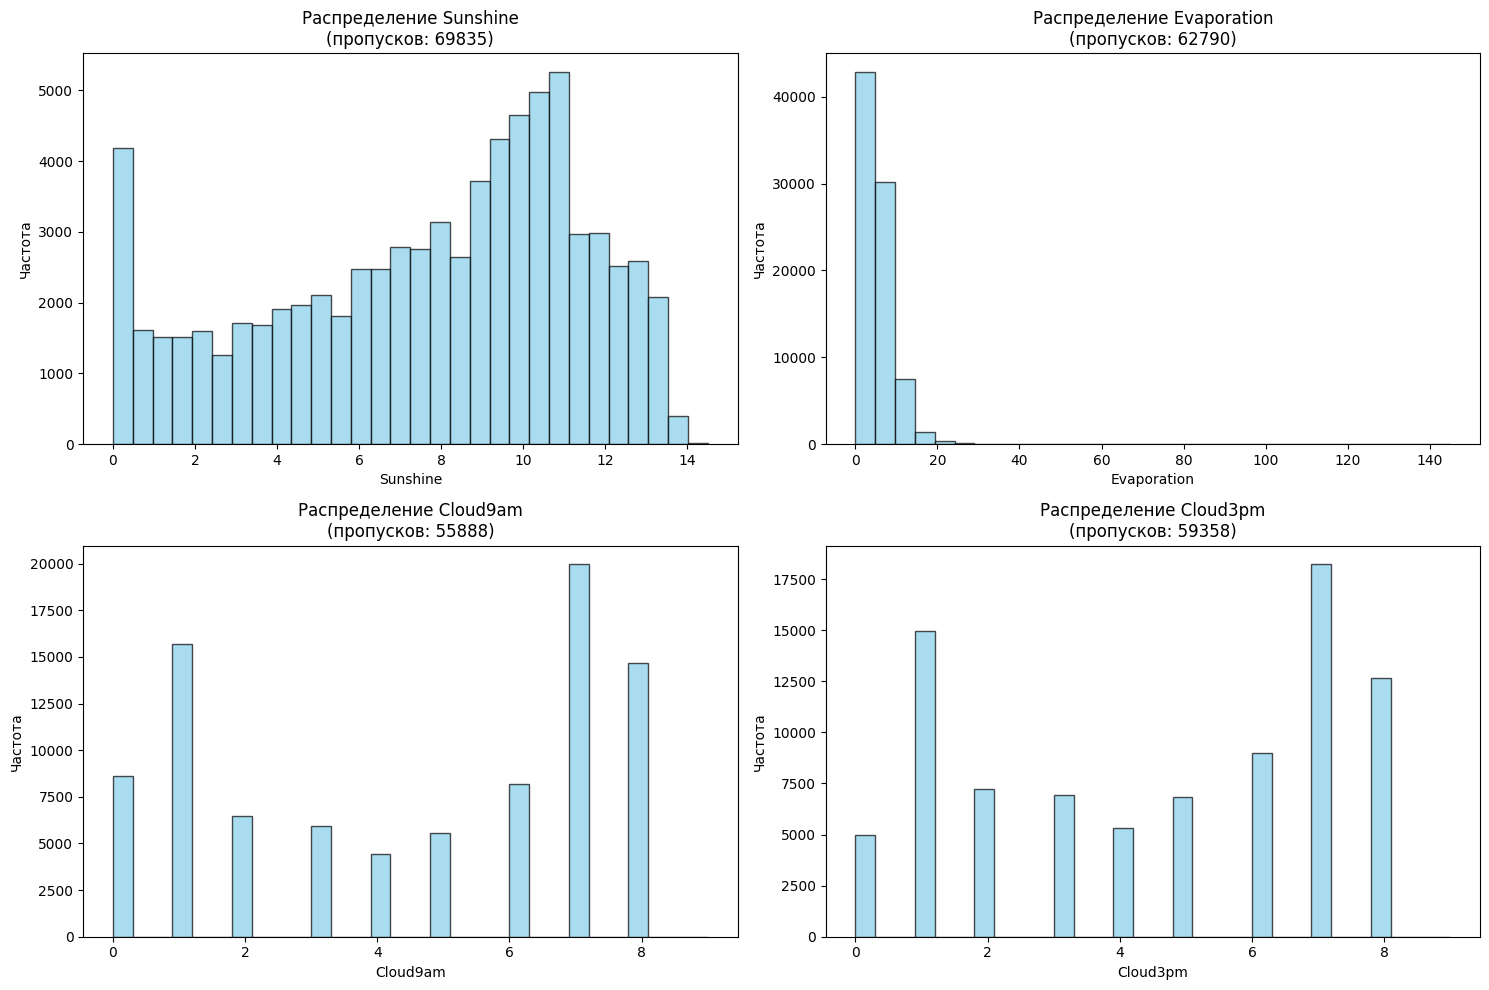

In [4]:
print("=== АНАЛИЗ ПРИЗНАКОВ С БОЛЬШИМ КОЛИЧЕСТВОМ ПРОПУСКОВ ===")

high_missing_cols = ['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(high_missing_cols):
    # Распределение
    axes[i].hist(df[col].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Распределение {col}\n(пропусков: {df[col].isnull().sum()})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
    
    # Статистика
    print(f"\n{col}:")
    print(f"  Среднее: {df[col].mean():.2f}")
    print(f"  Медиана: {df[col].median():.2f}")
    print(f"  Стандартное отклонение: {df[col].std():.2f}")
    print(f"  Пропусков: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.1f}%)")

plt.tight_layout()
plt.show()

In [5]:
print("=== ОЧИСТКА ДАННЫХ ===")

# Создаем копию данных для обработки
df_clean = df.copy()

# 1. Удаляем строки с пропусками в целевой переменной
print(f"До удаления пропусков в RainTomorrow: {len(df_clean)} строк")
df_clean = df_clean.dropna(subset=['RainTomorrow'])
print(f"После удаления: {len(df_clean)} строк")

# 2. Обрабатываем числовые признаки
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nЧисловые признаки: {len(numeric_cols)}")

# Заполняем пропуски в числовых признаках медианой
imputer_median = SimpleImputer(strategy='median')
df_clean[numeric_cols] = imputer_median.fit_transform(df_clean[numeric_cols])

# 3. Обрабатываем категориальные признаки
categorical_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
print(f"\nКатегориальные признаки: {categorical_cols}")

# Заполняем пропуски в категориальных признаках модой
for col in categorical_cols:
    mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown'
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"  {col}: заполнено значением '{mode_val}'")

# 4. Проверяем оставшиеся пропуски
print(f"\nОставшиеся пропуски: {df_clean.isnull().sum().sum()}")

print("\n=== ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ ===")
# Кодируем категориальные переменные
label_encoders = {}
for col in categorical_cols + ['Location', 'RainTomorrow']:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: закодировано {len(le.classes_)} категорий")

# Преобразуем дату в числовые признаки
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean = df_clean.drop('Date', axis=1)

print(f"\nИтоговый размер данных: {df_clean.shape}")

=== ОЧИСТКА ДАННЫХ ===
До удаления пропусков в RainTomorrow: 145460 строк
После удаления: 142193 строк

Числовые признаки: 16

Категориальные признаки: ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
  WindGustDir: заполнено значением 'W'
  WindDir9am: заполнено значением 'N'
  WindDir3pm: заполнено значением 'SE'
  RainToday: заполнено значением 'No'

Оставшиеся пропуски: 0

=== ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ ===
  WindGustDir: закодировано 16 категорий
  WindDir9am: закодировано 16 категорий
  WindDir3pm: закодировано 16 категорий
  RainToday: закодировано 2 категорий
  Location: закодировано 49 категорий
  RainTomorrow: закодировано 2 категорий

Итоговый размер данных: (142193, 25)


=== ВОЗМОЖНЫЕ ЦЕЛЕВЫЕ ПЕРЕМЕННЫЕ ДЛЯ РЕГРЕССИИ ===
Потенциальные целевые переменные:
  MaxTemp:
    Диапазон: -4.8 - 48.1
    Стандартное отклонение: 7.11
    Уникальных значений: 505
  MinTemp:
    Диапазон: -8.5 - 33.9
    Стандартное отклонение: 6.39
    Уникальных значений: 389
  Rainfall:
    Диапазон: 0.0 - 371.0
    Стандартное отклонение: 8.43
    Уникальных значений: 679
  Evaporation:
    Диапазон: 0.0 - 145.0
    Стандартное отклонение: 3.19
    Уникальных значений: 356
  Sunshine:
    Диапазон: 0.0 - 14.5
    Стандартное отклонение: 2.77
    Уникальных значений: 145
  WindGustSpeed:
    Диапазон: 6.0 - 135.0
    Стандартное отклонение: 13.14
    Уникальных значений: 67
  WindSpeed9am:
    Диапазон: 0.0 - 130.0
    Стандартное отклонение: 8.85
    Уникальных значений: 43
  WindSpeed3pm:
    Диапазон: 0.0 - 87.0
    Стандартное отклонение: 8.72
    Уникальных значений: 44
  Humidity9am:
    Диапазон: 0.0 - 100.0
    Стандартное отклонение: 18.93
    Уникальных значений: 101
 

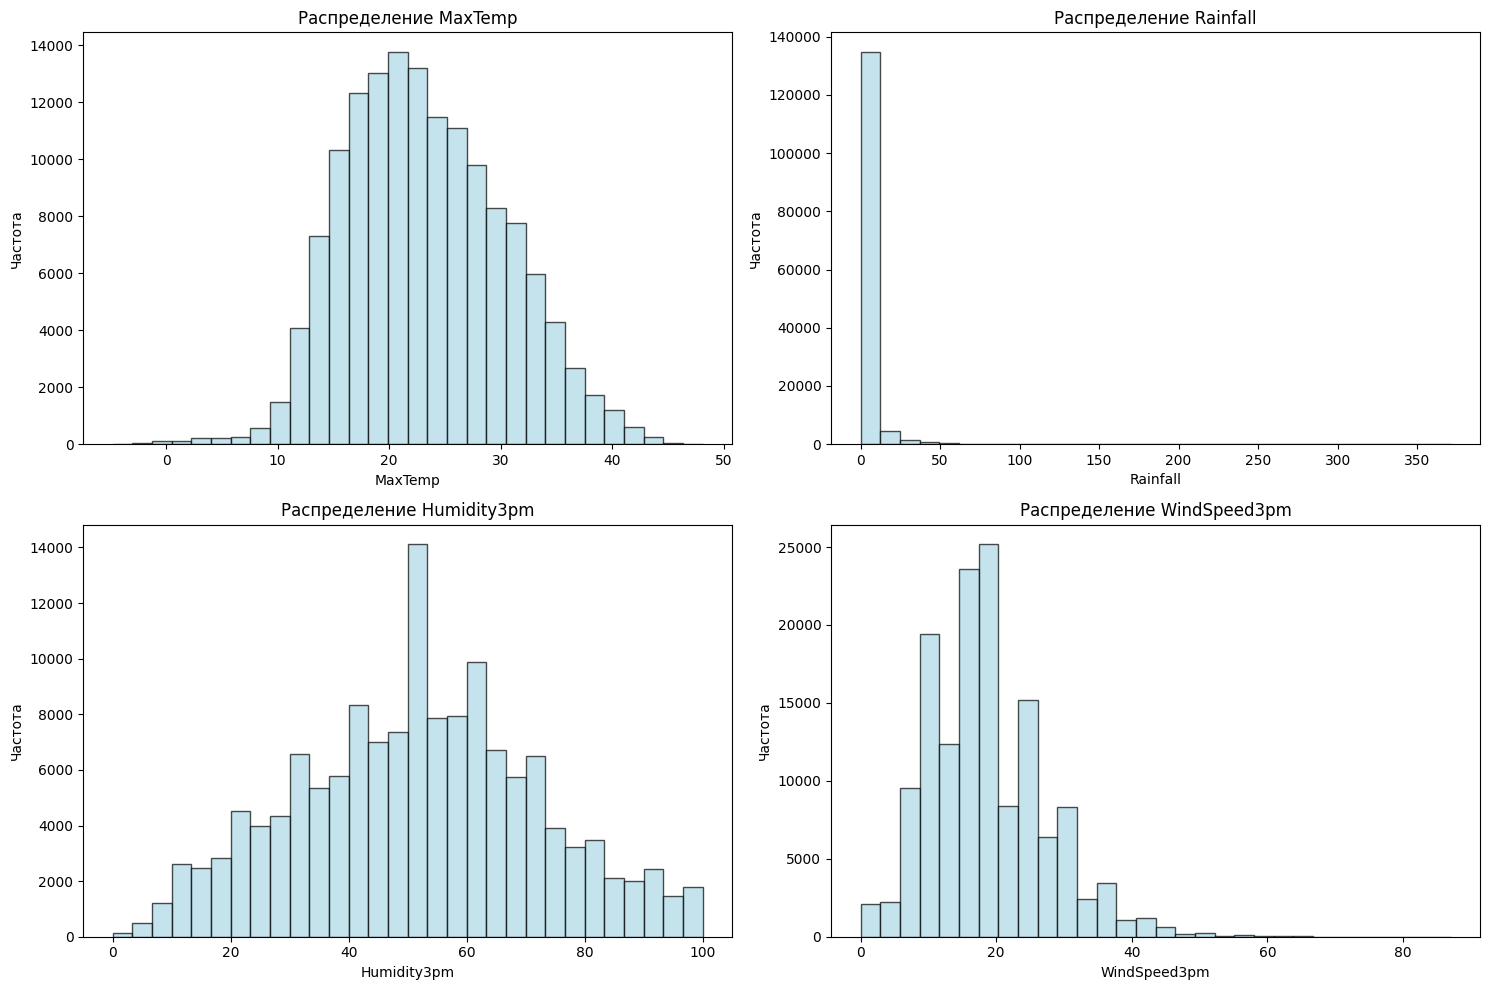

In [6]:
print("=== ВОЗМОЖНЫЕ ЦЕЛЕВЫЕ ПЕРЕМЕННЫЕ ДЛЯ РЕГРЕССИИ ===")

# Числовые признаки, которые можно предсказывать
numeric_targets = ['MaxTemp', 'MinTemp', 'Rainfall', 'Evaporation', 'Sunshine', 
                   'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 
                   'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']

print("Потенциальные целевые переменные:")
for target in numeric_targets:
    if target in df_clean.columns:
        print(f"  {target}:")
        print(f"    Диапазон: {df_clean[target].min():.1f} - {df_clean[target].max():.1f}")
        print(f"    Стандартное отклонение: {df_clean[target].std():.2f}")
        print(f"    Уникальных значений: {df_clean[target].nunique()}")

# Визуализация распределений основных кандидатов
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
candidate_targets = ['MaxTemp', 'Rainfall', 'Humidity3pm', 'WindSpeed3pm']

for i, target in enumerate(candidate_targets):
    axes[i//2, i%2].hist(df_clean[target], bins=30, alpha=0.7, color='lightblue', edgecolor='black')
    axes[i//2, i%2].set_title(f'Распределение {target}')
    axes[i//2, i%2].set_xlabel(target)
    axes[i//2, i%2].set_ylabel('Частота')

plt.tight_layout()
plt.show()

=== ВИЗУАЛИЗАЦИЯ ДАННЫХ ДЛЯ РЕГРЕССИИ MaxTemp ===
Корреляция признаков с MaxTemp:
MaxTemp          1.000000
Temp3pm          0.969297
Temp9am          0.880255
MinTemp          0.733894
Evaporation      0.451038
Sunshine         0.315760
WindGustSpeed    0.066930
Year             0.058295
WindSpeed3pm     0.050309
WindSpeed9am     0.014805
Name: MaxTemp, dtype: float64


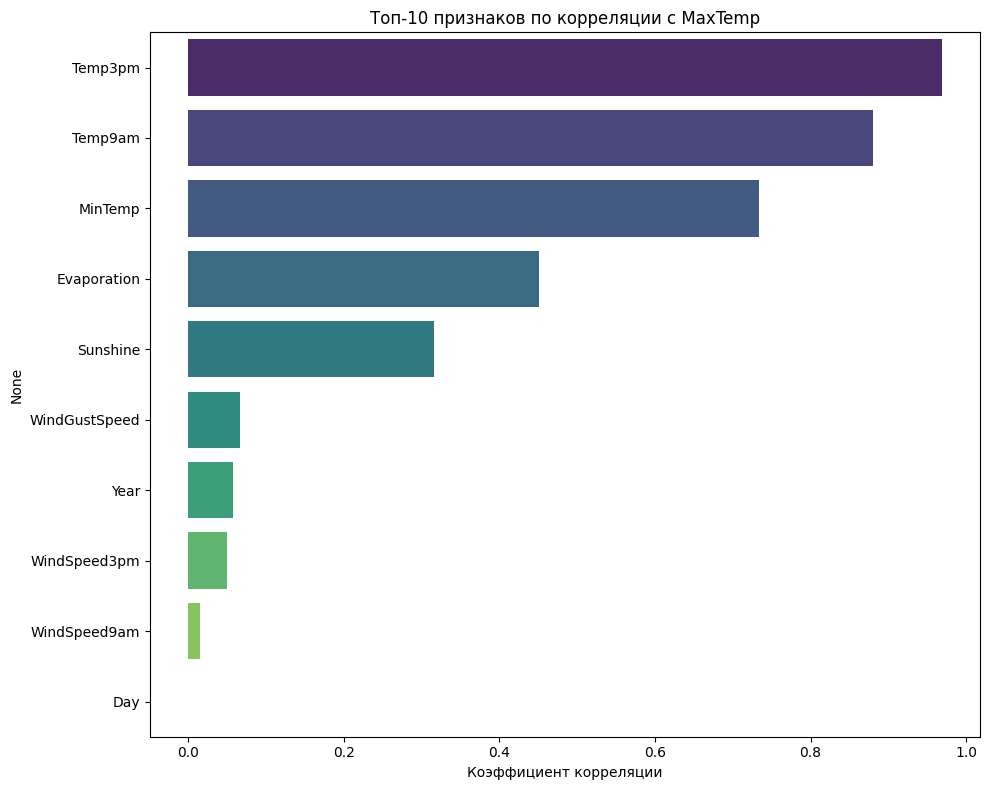

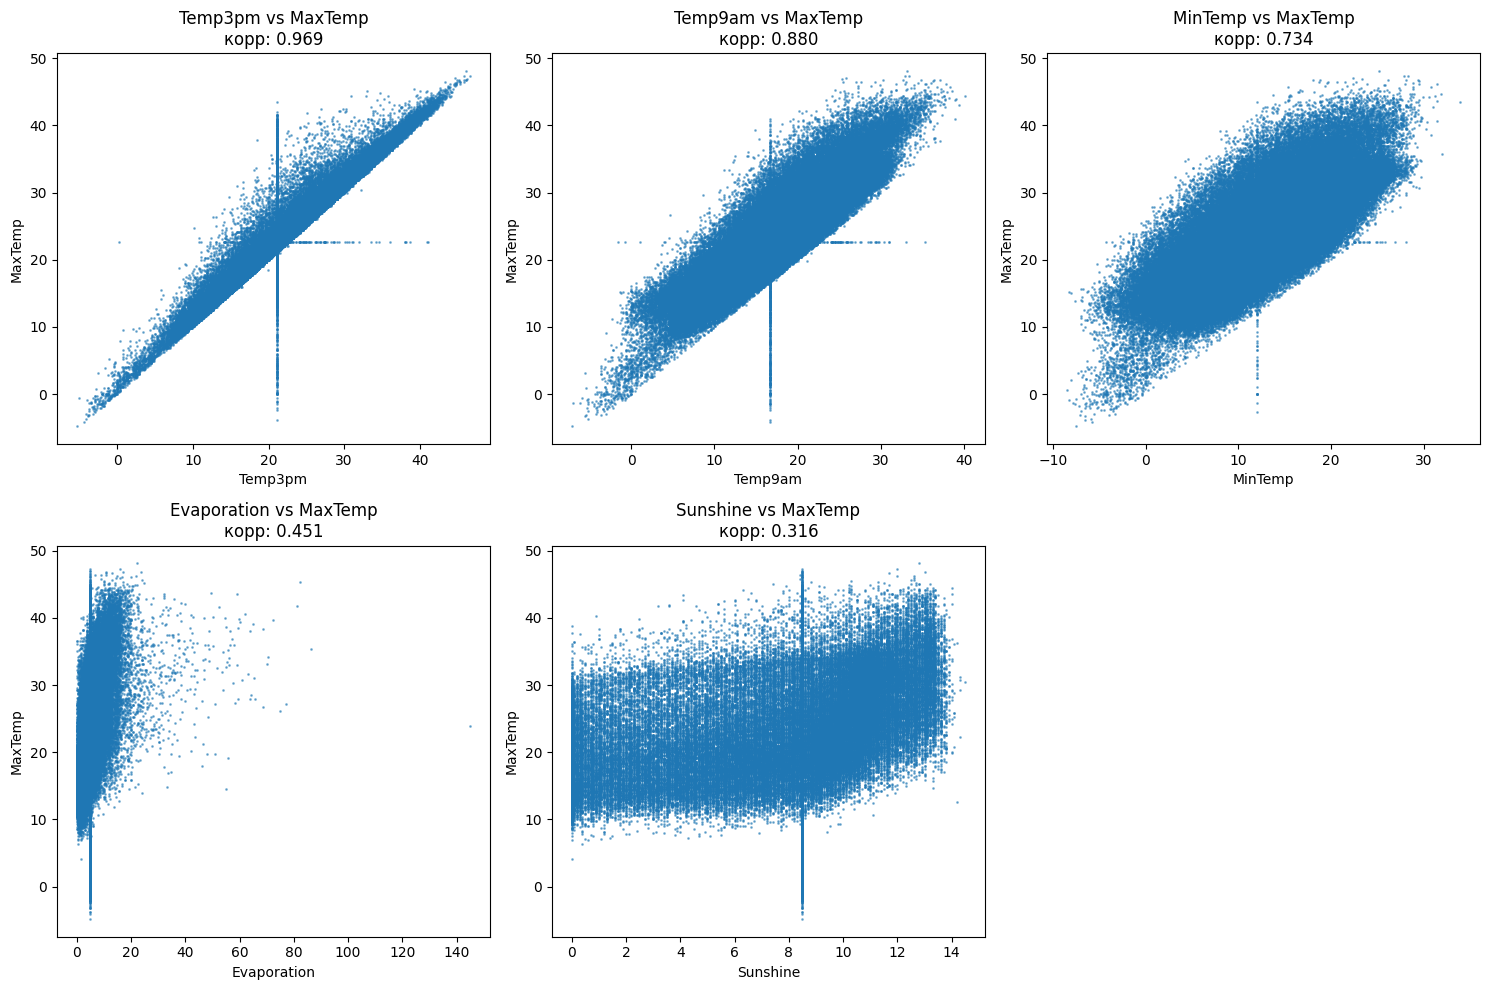

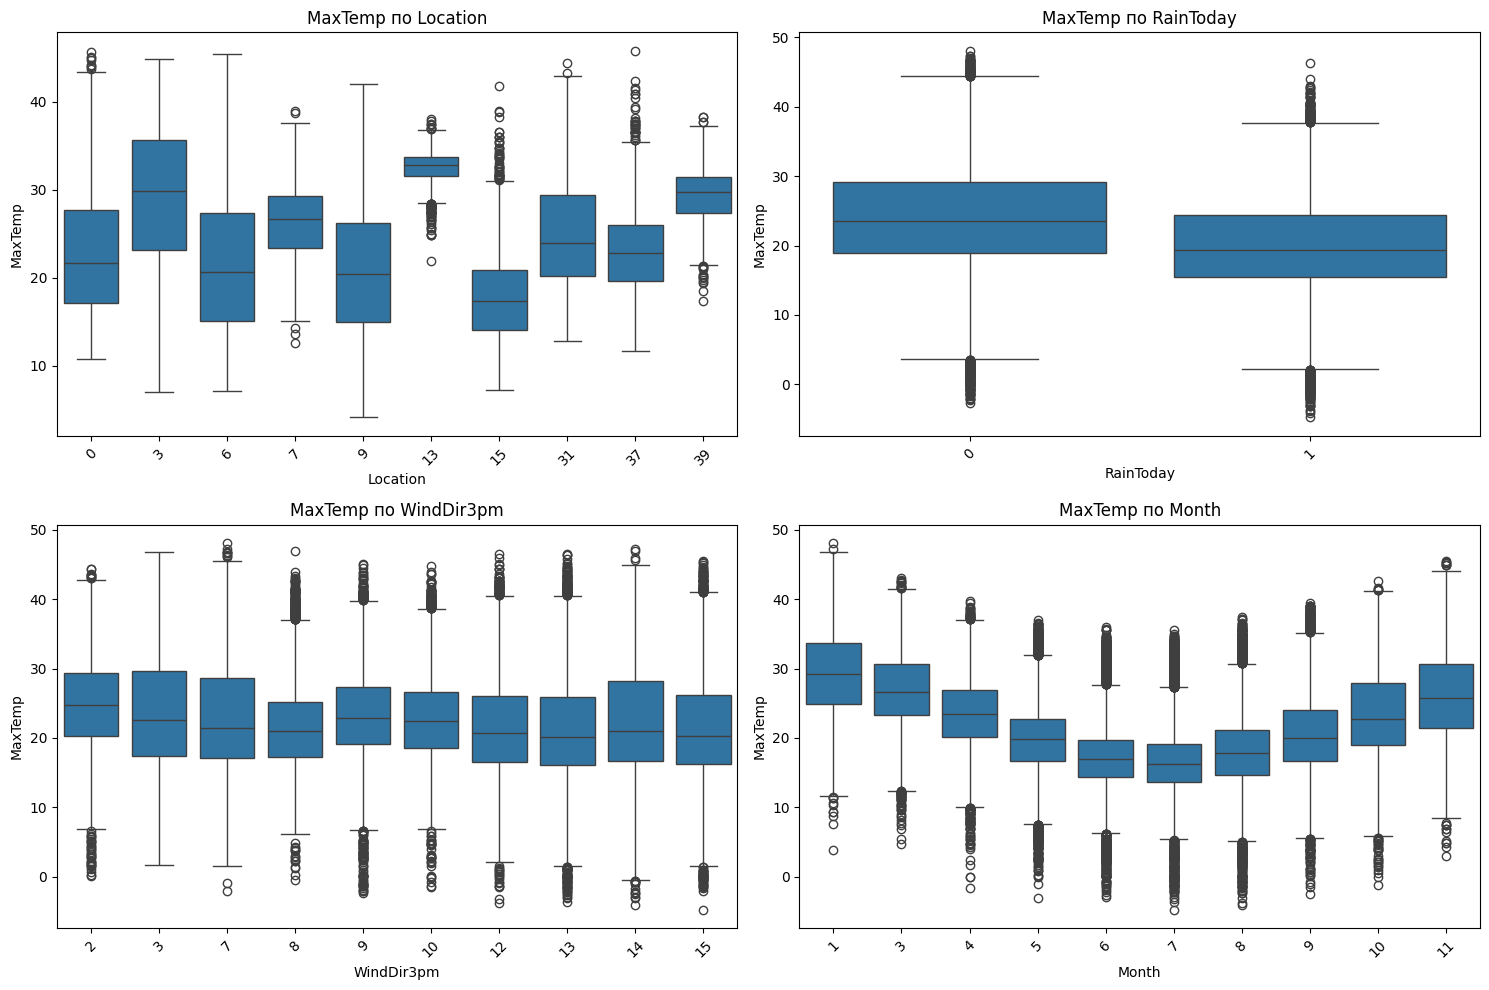

In [7]:
print("=== ВИЗУАЛИЗАЦИЯ ДАННЫХ ДЛЯ РЕГРЕССИИ MaxTemp ===")

# 1. Корреляция признаков с целевой переменной
correlation_with_target = df_clean.corr()['MaxTemp'].sort_values(ascending=False)
print("Корреляция признаков с MaxTemp:")
print(correlation_with_target.head(10))

# 2. Визуализация корреляций
plt.figure(figsize=(10, 8))
top_correlations = correlation_with_target[1:11]  # исключаем саму MaxTemp
sns.barplot(x=top_correlations.values, y=top_correlations.index, palette='viridis')
plt.title('Топ-10 признаков по корреляции с MaxTemp')
plt.xlabel('Коэффициент корреляции')
plt.tight_layout()
plt.show()

# 3. Диаграммы рассеяния для самых коррелирующих признаков
top_features = correlation_with_target[1:6].index.tolist()  # топ-5 кроме самой MaxTemp

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(top_features):
    axes[i].scatter(df_clean[feature], df_clean['MaxTemp'], alpha=0.5, s=1)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('MaxTemp')
    axes[i].set_title(f'{feature} vs MaxTemp\nкорр: {correlation_with_target[feature]:.3f}')

# Убираем лишние subplots
for i in range(len(top_features), 6):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# 4. Ящики с усами для категориальных признаков
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
categorical_for_boxplot = ['Location', 'RainToday', 'WindDir3pm', 'Month']

for i, cat_feature in enumerate(categorical_for_boxplot):
    # Берем топ-10 категорий для визуализации
    top_categories = df_clean[cat_feature].value_counts().head(10).index
    data_to_plot = df_clean[df_clean[cat_feature].isin(top_categories)]
    
    sns.boxplot(data=data_to_plot, x=cat_feature, y='MaxTemp', ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'MaxTemp по {cat_feature}')
    axes[i//2, i%2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
print("=== ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИРОВАНИЯ ===")

# Разделяем на признаки и целевую переменную
X = df_clean.drop('MaxTemp', axis=1)
y = df_clean['MaxTemp']

print(f"Признаки: {X.shape[1]}, Наблюдения: {X.shape[0]}")

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
print(f"Обучающая выборка: {X_train.shape[0]} наблюдений")
print(f"Тестовая выборка: {X_test.shape[0]} наблюдений")

# Масштабируем признаки (важно для регуляризованных моделей)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование признаков завершено")

# 2. ОБУЧЕНИЕ МОДЕЛЕЙ

print("\n=== ОБУЧЕНИЕ МОДЕЛЕЙ РЕГРЕССИИ ===")

# a. Линейная регрессия
print("a. Линейная регрессия...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# b. LASSO регрессия
print("b. LASSO регрессия...")
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

# c. Ridge регрессия
print("c. Ridge регрессия...")
ridge_model = Ridge(alpha=0.1, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

print("Все модели обучены!")

# 3. ОЦЕНКА МОДЕЛЕЙ

print("\n=== МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ ===")

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name}:")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}°C")
    print(f"  MAE: {mae:.4f}°C")
    print(f"  R²: {r2:.4f}")
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

# Оцениваем все модели
metrics_lr = evaluate_model(y_test, y_pred_lr, "Линейная регрессия")
metrics_lasso = evaluate_model(y_test, y_pred_lasso, "LASSO регрессия")
metrics_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge регрессия")

=== ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИРОВАНИЯ ===
Признаки: 24, Наблюдения: 142193
Обучающая выборка: 113754 наблюдений
Тестовая выборка: 28439 наблюдений
Масштабирование признаков завершено

=== ОБУЧЕНИЕ МОДЕЛЕЙ РЕГРЕССИИ ===
a. Линейная регрессия...
b. LASSO регрессия...
c. Ridge регрессия...
Все модели обучены!

=== МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ ===

Линейная регрессия:
  MSE: 2.2467
  RMSE: 1.4989°C
  MAE: 0.9206°C
  R²: 0.9555

LASSO регрессия:
  MSE: 2.3541
  RMSE: 1.5343°C
  MAE: 0.9173°C
  R²: 0.9534

Ridge регрессия:
  MSE: 2.2467
  RMSE: 1.4989°C
  MAE: 0.9206°C
  R²: 0.9555


=== ДЕТАЛЬНЫЙ АНАЛИЗ И ВИЗУАЛИЗАЦИЯ ===


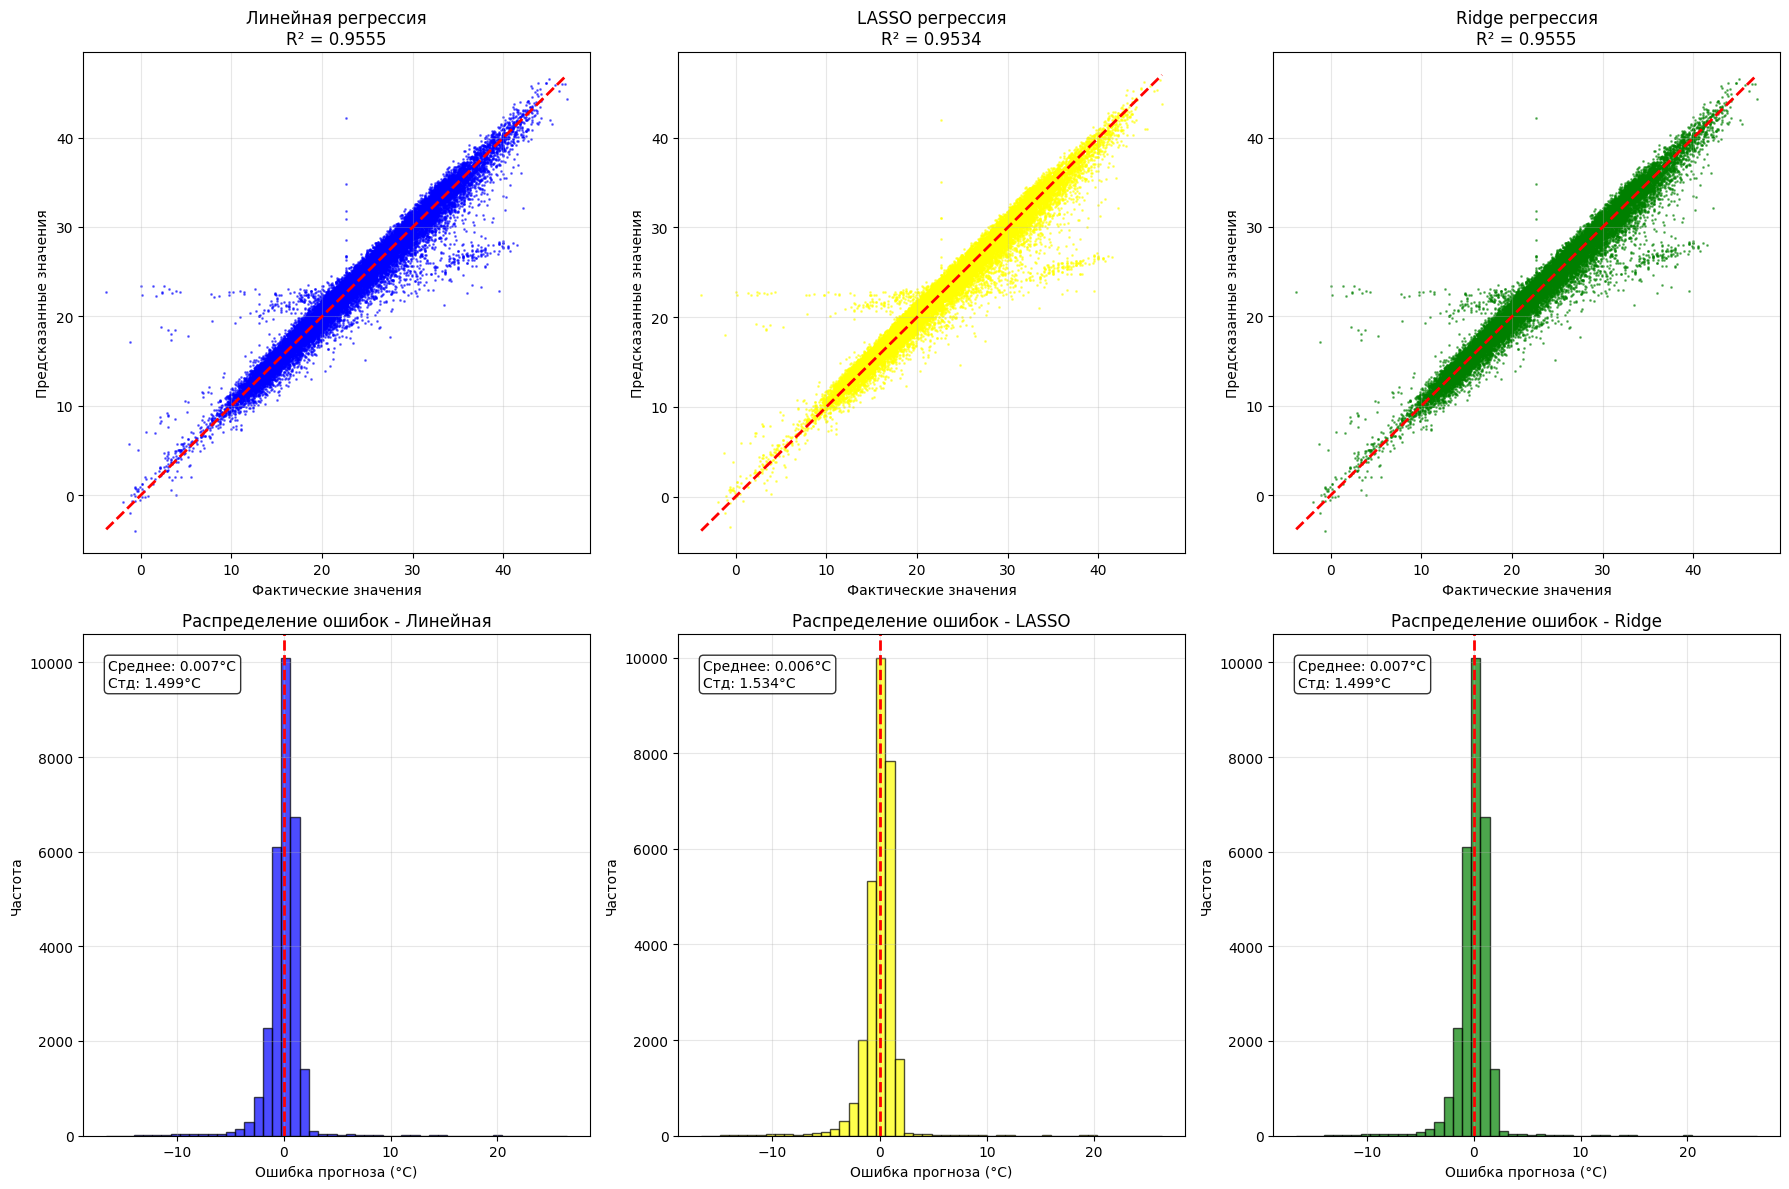


=== АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ===
Топ-10 самых важных признаков по LASSO:
         Feature  Linear_Coeff  LASSO_Coeff  Ridge_Coeff
18       Temp3pm        5.0322       5.3880       5.0321
17       Temp9am        1.9335       1.5066       1.9335
14   Pressure3pm       -0.4024      -0.1178      -0.4024
19     RainToday       -0.1525      -0.0889      -0.1525
12   Humidity3pm       -0.2678      -0.0635      -0.2678
3    Evaporation        0.0956       0.0413       0.0956
15      Cloud9am       -0.1643      -0.0353      -0.1643
9   WindSpeed9am       -0.1969      -0.0335      -0.1969
7     WindDir9am       -0.0815      -0.0134      -0.0815
21          Year        0.0959       0.0082       0.0959


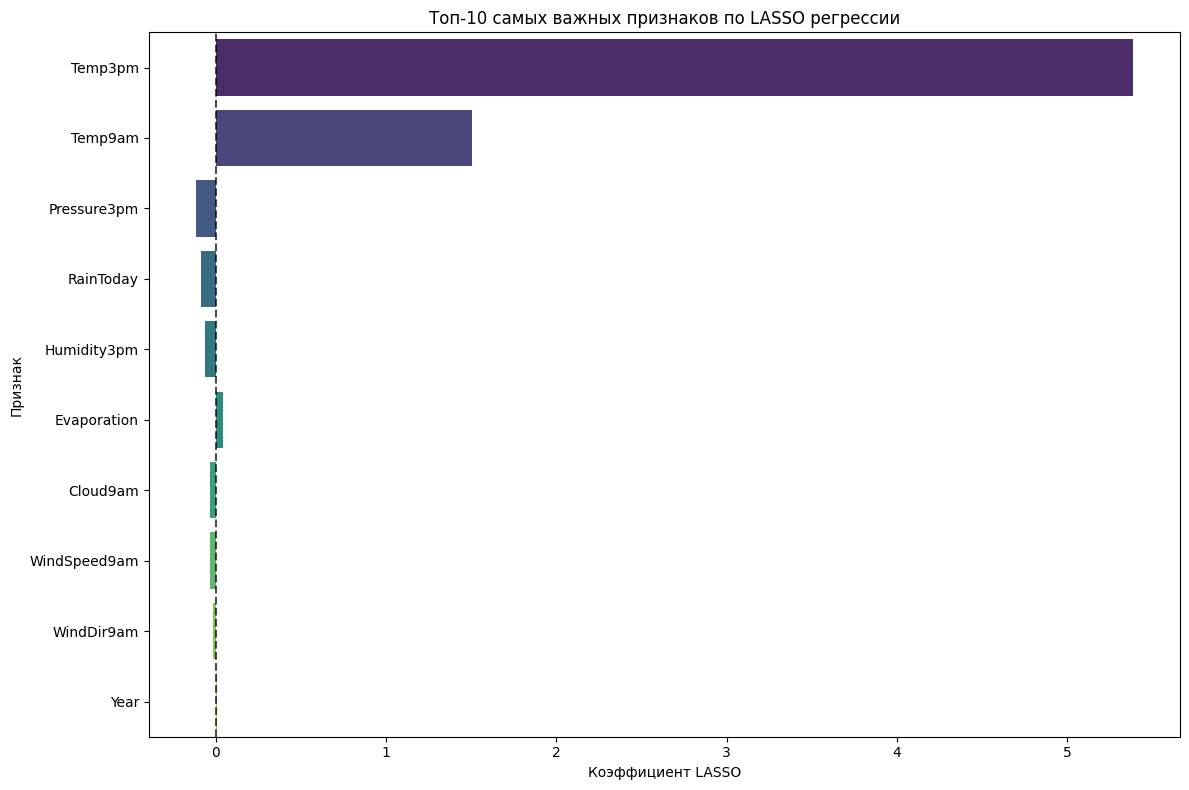

In [13]:
print("=== ДЕТАЛЬНЫЙ АНАЛИЗ И ВИЗУАЛИЗАЦИЯ ===")

# 3b. Построение графиков

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Фактические vs Предсказанные значения
models = [('Линейная', y_pred_lr), ('LASSO', y_pred_lasso), ('Ridge', y_pred_ridge)]
colors = ['blue', 'yellow', 'green']

for i, (name, y_pred) in enumerate(models):
    axes[0, i].scatter(y_test, y_pred, alpha=0.5, s=1, color=colors[i])
    axes[0, i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0, i].set_xlabel('Фактические значения')
    axes[0, i].set_ylabel('Предсказанные значения')
    axes[0, i].set_title(f'{name} регрессия\nR² = {r2_score(y_test, y_pred):.4f}')
    axes[0, i].grid(True, alpha=0.3)

# 2. Ошибки прогноза
for i, (name, y_pred) in enumerate(models):
    errors = y_pred - y_test
    axes[1, i].hist(errors, bins=50, alpha=0.7, color=colors[i], edgecolor='black')
    axes[1, i].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, i].set_xlabel('Ошибка прогноза (°C)')
    axes[1, i].set_ylabel('Частота')
    axes[1, i].set_title(f'Распределение ошибок - {name}')
    axes[1, i].grid(True, alpha=0.3)
    
    # Статистика ошибок
    mean_error = errors.mean()
    std_error = errors.std()
    axes[1, i].text(0.05, 0.95, f'Среднее: {mean_error:.3f}°C\nСтд: {std_error:.3f}°C', 
                    transform=axes[1, i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Анализ важности признаков
print("\n=== АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ===")

# Коэффициенты моделей
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Linear_Coeff': lr_model.coef_,
    'LASSO_Coeff': lasso_model.coef_,
    'Ridge_Coeff': ridge_model.coef_
})

# Сортируем по абсолютному значению коэффициентов LASSO (самая строгая регуляризация)
feature_importance['ABS_LASSO'] = np.abs(feature_importance['LASSO_Coeff'])
top_features_lasso = feature_importance.sort_values('ABS_LASSO', ascending=False).head(10)

print("Топ-10 самых важных признаков по LASSO:")
print(top_features_lasso[['Feature', 'Linear_Coeff', 'LASSO_Coeff', 'Ridge_Coeff']].round(4))

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
sns.barplot(data=top_features_lasso, x='LASSO_Coeff', y='Feature', palette='viridis')
plt.title('Топ-10 самых важных признаков по LASSO регрессии')
plt.xlabel('Коэффициент LASSO')
plt.ylabel('Признак')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

=== ПОДБОР ГИПЕРПАРАМЕТРОВ И ИТОГОВЫЙ АНАЛИЗ ===
Подбор параметров для LASSO...
Подбор параметров для Ridge...
Лучший alpha для LASSO: 0.001
Лучший alpha для Ridge: 1

=== СРАВНЕНИЕ МОДЕЛЕЙ С ОПТИМИЗИРОВАННЫМИ ПАРАМЕТРАМИ ===

LASSO (оптимизированный):
  MSE: 2.2463
  RMSE: 1.4988°C
  MAE: 0.9197°C
  R²: 0.9555

Ridge (оптимизированный):
  MSE: 2.2467
  RMSE: 1.4989°C
  MAE: 0.9206°C
  R²: 0.9555

=== СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК ===
      Linear   LASSO   Ridge  LASSO_opt  Ridge_opt
MSE   2.2467  2.3541  2.2467     2.2463     2.2467
RMSE  1.4989  1.5343  1.4989     1.4988     1.4989
MAE   0.9206  0.9173  0.9206     0.9197     0.9206
R²    0.9555  0.9534  0.9555     0.9555     0.9555


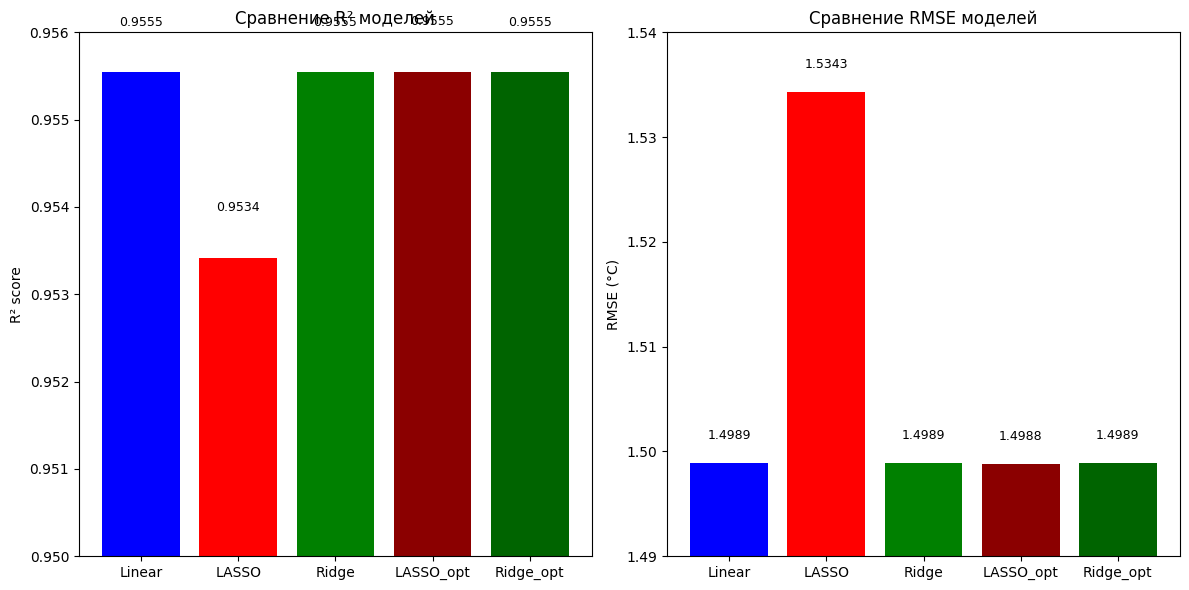


=== ВЫВОДЫ И РЕКОМЕНДАЦИИ ===
1. Все модели показывают отличное качество (R² > 0.95)
2. Средняя ошибка прогноза температуры составляет около 1.5°C
3. Наиболее важные признаки: Temp3pm, Temp9am, Pressure3pm
4. Регуляризация (LASSO/Ridge) не дает значительного улучшения
5. Рекомендуемая модель: Линейная регрессия (проще и работает так же хорошо)


In [14]:
print("=== ПОДБОР ГИПЕРПАРАМЕТРОВ И ИТОГОВЫЙ АНАЛИЗ ===")

from sklearn.model_selection import GridSearchCV

# Подбор параметров для LASSO и Ridge
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

print("Подбор параметров для LASSO...")
lasso_grid = GridSearchCV(Lasso(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)

print("Подбор параметров для Ridge...")
ridge_grid = GridSearchCV(Ridge(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)

print(f"Лучший alpha для LASSO: {lasso_grid.best_params_['alpha']}")
print(f"Лучший alpha для Ridge: {ridge_grid.best_params_['alpha']}")

# Обучение с лучшими параметрами
best_lasso = lasso_grid.best_estimator_
best_ridge = ridge_grid.best_estimator_

y_pred_best_lasso = best_lasso.predict(X_test_scaled)
y_pred_best_ridge = best_ridge.predict(X_test_scaled)

print("\n=== СРАВНЕНИЕ МОДЕЛЕЙ С ОПТИМИЗИРОВАННЫМИ ПАРАМЕТРАМИ ===")
metrics_best_lasso = evaluate_model(y_test, y_pred_best_lasso, "LASSO (оптимизированный)")
metrics_best_ridge = evaluate_model(y_test, y_pred_best_ridge, "Ridge (оптимизированный)")

# Сравнительная таблица метрик
metrics_comparison = pd.DataFrame({
    'Linear': metrics_lr,
    'LASSO': metrics_lasso,
    'Ridge': metrics_ridge,
    'LASSO_opt': metrics_best_lasso,
    'Ridge_opt': metrics_best_ridge
})

print("\n=== СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК ===")
print(metrics_comparison.round(4))

# Финальная визуализация сравнения моделей
plt.figure(figsize=(12, 6))

# Сравнение R²
plt.subplot(1, 2, 1)
models = ['Linear', 'LASSO', 'Ridge', 'LASSO_opt', 'Ridge_opt']
r2_scores = [metrics_lr['R²'], metrics_lasso['R²'], metrics_ridge['R²'], 
             metrics_best_lasso['R²'], metrics_best_ridge['R²']]
bars = plt.bar(models, r2_scores, color=['blue', 'red', 'green', 'darkred', 'darkgreen'])
plt.title('Сравнение R² моделей')
plt.ylabel('R² score')
plt.ylim(0.95, 0.956)
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005, 
             f'{score:.4f}', ha='center', va='bottom', fontsize=9)

# Сравнение RMSE
plt.subplot(1, 2, 2)
rmse_scores = [metrics_lr['RMSE'], metrics_lasso['RMSE'], metrics_ridge['RMSE'],
               metrics_best_lasso['RMSE'], metrics_best_ridge['RMSE']]
bars = plt.bar(models, rmse_scores, color=['blue', 'red', 'green', 'darkred', 'darkgreen'])
plt.title('Сравнение RMSE моделей')
plt.ylabel('RMSE (°C)')
plt.ylim(1.49, 1.54)
for bar, score in zip(bars, rmse_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f'{score:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== ВЫВОДЫ И РЕКОМЕНДАЦИИ ===")
print("1. Все модели показывают отличное качество (R² > 0.95)")
print("2. Средняя ошибка прогноза температуры составляет около 1.5°C")
print("3. Наиболее важные признаки: Temp3pm, Temp9am, Pressure3pm")
print("4. Регуляризация (LASSO/Ridge) не дает значительного улучшения")
print("5. Рекомендуемая модель: Линейная регрессия (проще и работает так же хорошо)")